In [3]:
pip install optuna shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.9 MB/s eta 0:00:00


# Pipeline de Clasificación: Circuitos Críticos con TDA + XGBoost + Optuna

## Estrategia General

**Objetivo:** Predecir si un circuito logístico es crítico (`critico = 1`) usando variables operativas + descriptores topológicos (homología persistente H0, H1 y persistence landscapes).

**Arquitectura del pipeline:**
1. Carga y validación rigurosa del dataset
2. Construcción del target (configurable: columna existente o percentil de `score_prioridad`)
3. Separación clara de bloques de features: operativas vs TDA
4. Preprocesamiento compatible con XGBoost (OrdinalEncoder para categóricas)
5. Split estratificado + manejo de desbalance con `scale_pos_weight`
6. Optimización de hiperparámetros con Optuna (CV estratificado, métrica F1)
7. Evaluación completa en test: métricas, matriz de confusión, curva ROC
8. Interpretabilidad: SHAP + feature importance separada por bloque

**Decisiones clave:**
- Se usa OrdinalEncoder (no OneHot) porque XGBoost aprende splits óptimos sobre ordinales sin explosión dimensional.
- `score_prioridad` se excluye de features si se usa para construir el target (evita leakage).
- Se filtra por `TDA_VALIDO = 1` en la versión principal del pipeline.
- Se prioriza F1 y recall de la clase positiva dado el contexto operativo (es peor no detectar un circuito crítico).

In [4]:
# =============================================================================
# 1. IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

import xgboost as xgb
import optuna
from optuna.samplers import TPESampler

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP no disponible. Se usará feature importance nativa de XGBoost.")

import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports completados exitosamente.")

Imports completados exitosamente.


In [6]:
# =============================================================================
# 2. CARGA DE DATOS
# =============================================================================


df_raw = pd.read_csv("circuitos_TDA.csv")

print(f"Dataset cargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"\nColumnas disponibles ({df_raw.shape[1]}):")
print(df_raw.columns.tolist())
df_raw.head()

Dataset cargado: 553 filas x 53 columnas

Columnas disponibles (53):
['CIRCUITO', 'PLANTA_ORIGEN', 'DESTINO', 'NOMBRE_TIPO_CAMION', 'frecuencia_registros', 'tiempo_programacion_mediano_h', 'tiempo_programacion_promedio_h', 'tiempo_programacion_std_h', 'tiempo_transito_mediano_h', 'tiempo_transito_promedio_h', 'tiempo_transito_std_h', 'tiempo_transito_iqr_h', 'peso_promedio', 'peso_mediano', 'peso_bruto_promedio', 'ancho_promedio', 'espesor_promedio', 'proporcion_linea_critica', 'proporcion_viaje_incompleto', 'proporcion_anomalia_tiempo', 'frecuencia_viajes', 'participacion_total', 'material_pesado', 'material_ancho', 'score_prioridad', 'TDA_VALIDO', 'TDA_N_PUNTOS', 'H0_N_FEATURES', 'H0_MAX_PERS', 'H0_MEAN_PERS', 'H0_SUM_PERS', 'H0_STD_PERS', 'H0_TOP1_PERS', 'H0_TOP2_PERS', 'H0_TOP3_PERS', 'H1_N_FEATURES', 'H1_MAX_PERS', 'H1_SUM_PERS', 'LANDSCAPE_01', 'LANDSCAPE_02', 'LANDSCAPE_03', 'LANDSCAPE_04', 'LANDSCAPE_05', 'LANDSCAPE_06', 'LANDSCAPE_07', 'LANDSCAPE_08', 'LANDSCAPE_09', 'LANDSCAP

,CIRCUITO,PLANTA_ORIGEN,DESTINO,NOMBRE_TIPO_CAMION,frecuencia_registros,tiempo_programacion_mediano_h,tiempo_programacion_promedio_h,tiempo_programacion_std_h,tiempo_transito_mediano_h,tiempo_transito_promedio_h,...,LANDSCAPE_06,LANDSCAPE_07,LANDSCAPE_08,LANDSCAPE_09,LANDSCAPE_10,LANDSCAPE_11,LANDSCAPE_12,LANDSCAPE_13,LANDSCAPE_14,LANDSCAPE_15
0,Pesquería -> Churubusco | Plataforma 3 ejes Ne...,Pesquería,Churubusco,Plataforma 3 ejes Neumática BIG COIL,7820,708.100000,688.038211,68.200027,1.783333,4.063387,...,0.0,0.75,0.533866,0.000000,0.0,0.0,0.75,0.516956,0.000000,0.0
1,Juventud -> CSI San Luis Potosí | Plataforma 2...,Juventud,CSI San Luis Potosí,Plataforma 2 ejes Neumática,22,NaN,NaN,NaN,115.616667,113.648246,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Pesquería -> CSI Apodaca | Plataforma 2 ejes N...,Pesquería,CSI Apodaca,Plataforma 2 ejes Neumática,20,NaN,NaN,NaN,8.750000,8.744444,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Churubusco -> Guerrero | Plataforma 3 ejes Neu...,Churubusco,Guerrero,Plataforma 3 ejes Neumática BIG COIL,564,688.716667,663.566667,54.434499,0.266667,1.370576,...,0.0,0.75,0.989020,0.239020,0.0,0.0,0.75,0.966696,0.216696,0.0
4,Pesquería -> CSI San Luis Potosí | Plataforma ...,Pesquería,CSI San Luis Potosí,Plataforma larga 48 pies,29,NaN,NaN,NaN,75.766667,69.422917,...,0.0,0.75,1.211319,0.461319,0.0,0.0,0.75,0.848305,0.098305,0.0


In [7]:
# =============================================================================
# 3. VALIDACIÓN DE DATOS
# =============================================================================

print("="*60)
print("VALIDACIÓN DEL DATASET")
print("="*60)

# 3.1 Shape y tipos
print(f"\n━━ Shape: {df_raw.shape}")
print(f"\n━━ Tipos de datos:")
print(df_raw.dtypes.value_counts())

# 3.2 Nulos
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct}).query('nulos > 0').sort_values('pct', ascending=False)
if len(nulos_df) > 0:
    print(f"\n━━ Columnas con nulos ({len(nulos_df)}):")
    print(nulos_df)
else:
    print("\n━━ No hay valores nulos.")

# 3.3 Duplicados por CIRCUITO
n_circuitos = df_raw['CIRCUITO'].nunique()
n_filas = len(df_raw)
print(f"\n━━ Unicidad de CIRCUITO:")
print(f"   Filas totales: {n_filas}")
print(f"   Circuitos únicos: {n_circuitos}")
if n_filas != n_circuitos:
    print(f"   ⚠️ HAY DUPLICADOS: {n_filas - n_circuitos} filas duplicadas")
    print("   Se recomienda deduplicar antes de continuar.")
else:
    print("   ✅ Una fila por circuito (sin duplicados).")

# 3.4 TDA_VALIDO: impacto del filtro
if 'TDA_VALIDO' in df_raw.columns:
    n_valido = df_raw['TDA_VALIDO'].sum()
    n_invalido = n_filas - n_valido
    print(f"\n━━ Filtro TDA_VALIDO:")
    print(f"   TDA_VALIDO=1: {n_valido} ({n_valido/n_filas*100:.1f}%)")
    print(f"   TDA_VALIDO=0: {n_invalido} ({n_invalido/n_filas*100:.1f}%) ← se perderían")
else:
    print("\n━━ Columna TDA_VALIDO no encontrada.")

# 3.5 TDA_N_PUNTOS como metadato de calidad
if 'TDA_N_PUNTOS' in df_raw.columns:
    print(f"\n━━ TDA_N_PUNTOS (metadato de calidad TDA):")
    print(df_raw['TDA_N_PUNTOS'].describe())

# 3.6 Estadísticas descriptivas generales
print(f"\n━━ Estadísticas descriptivas (numéricas):")
display(df_raw.describe())

VALIDACIÓN DEL DATASET

━━ Shape: (553, 53)

━━ Tipos de datos:
float64    44
int64       5
object      4
Name: count, dtype: int64

━━ Columnas con nulos (35):
                                nulos    pct
tiempo_programacion_std_h         438  79.20
tiempo_programacion_mediano_h     434  78.48
tiempo_programacion_promedio_h    434  78.48
H0_N_FEATURES                     329  59.49
H0_MAX_PERS                       329  59.49
TDA_N_PUNTOS                      329  59.49
H0_TOP2_PERS                      329  59.49
H0_TOP1_PERS                      329  59.49
H0_STD_PERS                       329  59.49
H0_SUM_PERS                       329  59.49
H0_MEAN_PERS                      329  59.49
H1_N_FEATURES                     329  59.49
H0_TOP3_PERS                      329  59.49
H1_MAX_PERS                       329  59.49
LANDSCAPE_04                      329  59.49
LANDSCAPE_03                      329  59.49
LANDSCAPE_02                      329  59.49
LANDSCAPE_01                 

,frecuencia_registros,tiempo_programacion_mediano_h,tiempo_programacion_promedio_h,tiempo_programacion_std_h,tiempo_transito_mediano_h,tiempo_transito_promedio_h,tiempo_transito_std_h,tiempo_transito_iqr_h,peso_promedio,peso_mediano,...,LANDSCAPE_06,LANDSCAPE_07,LANDSCAPE_08,LANDSCAPE_09,LANDSCAPE_10,LANDSCAPE_11,LANDSCAPE_12,LANDSCAPE_13,LANDSCAPE_14,LANDSCAPE_15
count,553.000000,119.000000,119.000000,115.000000,318.000000,318.000000,311.000000,318.000000,553.000000,553.000000,...,224.0,224.00,224.000000,224.000000,224.000000,224.0,224.000000,224.000000,224.000000,224.000000
mean,470.200723,609.553852,599.421299,38.675566,13.651494,17.070778,11.756164,10.057652,9.572042,9.478805,...,0.0,0.75,1.027237,0.385433,0.077374,0.0,0.749254,0.776911,0.170293,0.033007
std,1194.017168,104.003477,102.875296,64.099363,25.288646,25.652293,11.365531,17.947283,6.697340,7.063492,...,0.0,0.00,0.346614,0.433277,0.335011,0.0,0.009564,0.339314,0.315226,0.250335
min,5.000000,157.450000,185.722222,0.000000,0.100000,0.175000,0.000000,0.000000,0.577521,0.438000,...,0.0,0.75,0.074727,0.000000,0.000000,0.0,0.609185,0.000000,0.000000,0.000000
25%,40.000000,577.308333,563.501111,0.000000,1.275000,3.298780,3.888944,0.795833,3.349473,2.756000,...,0.0,0.75,0.778583,0.028583,0.000000,0.0,0.750000,0.533143,0.000000,0.000000
50%,113.000000,618.033333,613.650000,2.713546,2.550000,5.910359,8.274663,3.445833,8.377036,7.820000,...,0.0,0.75,1.026419,0.276419,0.000000,0.0,0.750000,0.770018,0.020018,0.000000
75%,376.000000,695.441667,676.273485,62.518901,14.541667,19.638005,14.557609,8.478125,14.762360,15.205000,...,0.0,0.75,1.329998,0.579998,0.000000,0.0,0.750000,0.962038,0.212038,0.000000
max,19507.000000,716.500000,716.944444,343.617511,169.350000,146.613546,56.712198,125.633333,30.325119,31.521000,...,0.0,0.75,1.500000,2.250000,3.000000,0.0,0.750000,1.500000,2.250000,2.861792


⚠️ Construyendo 'critico' desde 'score_prioridad' (percentil 75)
   Umbral calculado (P75): 0.2173
   ⚠️ IMPORTANTE: 'score_prioridad' se excluirá de features para evitar leakage.

━━ Filtro TDA_VALIDO=1 aplicado: 553 → 224 registros (329 eliminados)

━━ Distribución del target 'critico':
   Clase 0: 158 (70.5%)
   Clase 1: 66 (29.5%)


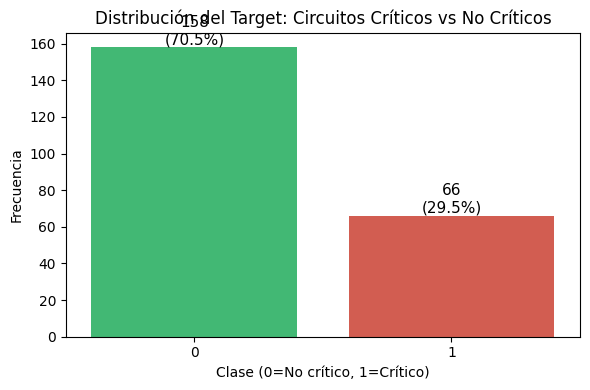


━━ Ratio desbalance (neg/pos): 2.39
   Se usará scale_pos_weight=2.39 en XGBoost.


In [8]:
# =============================================================================
# 4. DEFINICIÓN DEL TARGET
# =============================================================================

TARGET_COL = 'critico'
USAR_TARGET_EXISTENTE = True
PERCENTIL_UMBRAL = 75

# --- Opción 1: Target existente ---
if USAR_TARGET_EXISTENTE and TARGET_COL in df_raw.columns:
    print(f"✅ Usando columna existente '{TARGET_COL}'")
    df = df_raw.copy()

# --- Opción 2: Construir target desde score_prioridad ---
else:
    print(f"⚠️ Construyendo '{TARGET_COL}' desde 'score_prioridad' (percentil {PERCENTIL_UMBRAL})")
    umbral = df_raw['score_prioridad'].quantile(PERCENTIL_UMBRAL / 100)
    print(f"   Umbral calculado (P{PERCENTIL_UMBRAL}): {umbral:.4f}")
    df = df_raw.copy()
    df[TARGET_COL] = (df['score_prioridad'] >= umbral).astype(int)
    print(f"   ⚠️ IMPORTANTE: 'score_prioridad' se excluirá de features para evitar leakage.")

# Filtrar por TDA_VALIDO = 1
FILTRAR_TDA_VALIDO = True

if FILTRAR_TDA_VALIDO and 'TDA_VALIDO' in df.columns:
    n_antes = len(df)
    df = df[df['TDA_VALIDO'] == 1].reset_index(drop=True)
    n_despues = len(df)
    print(f"\n━━ Filtro TDA_VALIDO=1 aplicado: {n_antes} → {n_despues} registros ({n_antes - n_despues} eliminados)")

# Distribución del target
print(f"\n━━ Distribución del target '{TARGET_COL}':")
target_dist = df[TARGET_COL].value_counts()
target_pct = df[TARGET_COL].value_counts(normalize=True) * 100
for val in sorted(target_dist.index):
    print(f"   Clase {val}: {target_dist[val]} ({target_pct[val]:.1f}%)")

# Visualización de distribución del target
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL, palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Distribución del Target: Circuitos Críticos vs No Críticos')
ax.set_xlabel('Clase (0=No crítico, 1=Crítico)')
ax.set_ylabel('Frecuencia')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# Ratio de desbalance para scale_pos_weight
n_neg = (df[TARGET_COL] == 0).sum()
n_pos = (df[TARGET_COL] == 1).sum()
scale_pos_weight_value = n_neg / n_pos
print(f"\n━━ Ratio desbalance (neg/pos): {scale_pos_weight_value:.2f}")
print(f"   Se usará scale_pos_weight={scale_pos_weight_value:.2f} en XGBoost.")

In [9]:
# =============================================================================
# 5. DEFINICIÓN DE FEATURES
# =============================================================================

# --- Bloque OPERATIVO ---
FEATURES_OPERATIVAS = [
    'PLANTA_ORIGEN',
    'DESTINO',
    'NOMBRE_TIPO_CAMION',
    'frecuencia_registros',
    'tiempo_programacion_mediano_h',
    'tiempo_programacion_promedio_h',
    'tiempo_programacion_std_h',
    'tiempo_transito_mediano_h',
    'tiempo_transito_promedio_h',
    'tiempo_transito_std_h',
    'tiempo_transito_iqr_h',
    'peso_promedio',
    'peso_mediano',
    'peso_bruto_promedio',
    'ancho_promedio',
    'espesor_promedio',
    'proporcion_linea_critica',
    'proporcion_viaje_incompleto',
    'proporcion_anomalia_tiempo',
    'frecuencia_viajes',
    'participacion_total',
    'material_pesado',
    'material_ancho',
]

# --- Bloque TDA (Topological Data Analysis) ---
FEATURES_TDA = [
    'H0_N_FEATURES',
    'H0_MAX_PERS',
    'H0_MEAN_PERS',
    'H0_SUM_PERS',
    'H0_STD_PERS',
    'H0_TOP1_PERS',
    'H0_TOP2_PERS',
    'H0_TOP3_PERS',
    'H1_N_FEATURES',
    'H1_MAX_PERS',
    'H1_SUM_PERS',
] + [f'LANDSCAPE_{i:02d}' for i in range(1, 16)]

# --- Exclusiones por leakage ---
# Si el target se construyó desde score_prioridad, lo excluimos
EXCLUIR_LEAKAGE = []
if not USAR_TARGET_EXISTENTE:
    EXCLUIR_LEAKAGE.append('score_prioridad')
    # Verificar si score_prioridad está en features operativas
    FEATURES_OPERATIVAS = [f for f in FEATURES_OPERATIVAS if f != 'score_prioridad']

# --- Features completas ---
ALL_FEATURES = FEATURES_OPERATIVAS + FEATURES_TDA

# Verificar que todas las features existen en el dataframe
missing_features = [f for f in ALL_FEATURES if f not in df.columns]
if missing_features:
    print(f"⚠️ Features no encontradas en el dataset: {missing_features}")
    ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
    FEATURES_OPERATIVAS = [f for f in FEATURES_OPERATIVAS if f in df.columns]
    FEATURES_TDA = [f for f in FEATURES_TDA if f in df.columns]
else:
    print("✅ Todas las features existen en el dataset.")

print(f"\n━━ Resumen de features:")
print(f"   Features operativas: {len(FEATURES_OPERATIVAS)}")
print(f"   Features TDA: {len(FEATURES_TDA)}")
print(f"   Total features: {len(ALL_FEATURES)}")
print(f"\n━━ Features OPERATIVAS:")
for f in FEATURES_OPERATIVAS:
    print(f"   - {f}")
print(f"\n━━ Features TDA:")
for f in FEATURES_TDA:
    print(f"   - {f}")

✅ Todas las features existen en el dataset.

━━ Resumen de features:
   Features operativas: 23
   Features TDA: 26
   Total features: 49

━━ Features OPERATIVAS:
   - PLANTA_ORIGEN
   - DESTINO
   - NOMBRE_TIPO_CAMION
   - frecuencia_registros
   - tiempo_programacion_mediano_h
   - tiempo_programacion_promedio_h
   - tiempo_programacion_std_h
   - tiempo_transito_mediano_h
   - tiempo_transito_promedio_h
   - tiempo_transito_std_h
   - tiempo_transito_iqr_h
   - peso_promedio
   - peso_mediano
   - peso_bruto_promedio
   - ancho_promedio
   - espesor_promedio
   - proporcion_linea_critica
   - proporcion_viaje_incompleto
   - proporcion_anomalia_tiempo
   - frecuencia_viajes
   - participacion_total
   - material_pesado
   - material_ancho

━━ Features TDA:
   - H0_N_FEATURES
   - H0_MAX_PERS
   - H0_MEAN_PERS
   - H0_SUM_PERS
   - H0_STD_PERS
   - H0_TOP1_PERS
   - H0_TOP2_PERS
   - H0_TOP3_PERS
   - H1_N_FEATURES
   - H1_MAX_PERS
   - H1_SUM_PERS
   - LANDSCAPE_01
   - LANDSCAPE_02

In [10]:
# =============================================================================
# 6. PREPROCESAMIENTO
# =============================================================================
# Estrategia:
# - Categóricas: OrdinalEncoder (XGBoost aprende splits óptimos sobre ordinales;
#   evita explosión dimensional de OneHot con alta cardinalidad en PLANTA_ORIGEN/DESTINO)
# - Numéricas: Imputación con mediana (robusta a outliers)
# - XGBoost maneja NaN nativamente, pero pre-imputamos para consistencia del pipeline

# Separar X e y
X = df[ALL_FEATURES].copy()
y = df[TARGET_COL].copy()

# Identificar columnas categóricas y numéricas
CAT_COLS = X.select_dtypes(include=['object', 'category']).columns.tolist()
NUM_COLS = X.select_dtypes(include=['number']).columns.tolist()

print(f"Columnas categóricas ({len(CAT_COLS)}): {CAT_COLS}")
print(f"Columnas numéricas ({len(NUM_COLS)}): {len(NUM_COLS)} features")

# --- Imputación de nulos ---
# Numéricas: mediana
if X[NUM_COLS].isnull().any().any():
    imputer_num = SimpleImputer(strategy='median')
    X[NUM_COLS] = imputer_num.fit_transform(X[NUM_COLS])
    print(f"\n✅ Nulos numéricos imputados con mediana.")
else:
    imputer_num = None
    print(f"\n✅ Sin nulos en columnas numéricas.")

# Categóricas: rellenar con 'MISSING' antes de codificar
if CAT_COLS:
    X[CAT_COLS] = X[CAT_COLS].fillna('MISSING')
    print(f"✅ Nulos categóricos reemplazados con 'MISSING'.")

# --- Codificación de categóricas ---
# OrdinalEncoder: XGBoost puede encontrar splits óptimos sobre valores ordinales.
# Ventaja sobre OneHot: no genera cientos de columnas sparse para PLANTA_ORIGEN/DESTINO.
# Alternativa futura: CatBoost con encoding nativo, o TargetEncoder de category_encoders.
if CAT_COLS:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[CAT_COLS] = encoder.fit_transform(X[CAT_COLS])
    print(f"✅ Categóricas codificadas con OrdinalEncoder.")
    print(f"   Cardinalidades:")
    for col in CAT_COLS:
        card = int(X[col].nunique())
        print(f"   - {col}: {card} categorías")
else:
    encoder = None

print(f"\n━━ Dataset preprocesado: {X.shape[0]} filas x {X.shape[1]} features")
print(f"   Tipos finales: {X.dtypes.value_counts().to_dict()}")

Columnas categóricas (3): ['PLANTA_ORIGEN', 'DESTINO', 'NOMBRE_TIPO_CAMION']
Columnas numéricas (46): 46 features

✅ Nulos numéricos imputados con mediana.
✅ Nulos categóricos reemplazados con 'MISSING'.
✅ Categóricas codificadas con OrdinalEncoder.
   Cardinalidades:
   - PLANTA_ORIGEN: 9 categorías
   - DESTINO: 23 categorías
   - NOMBRE_TIPO_CAMION: 10 categorías

━━ Dataset preprocesado: 224 filas x 49 features
   Tipos finales: {dtype('float64'): 49}


In [11]:
# =============================================================================
# 7. TRAIN / TEST SPLIT ESTRATIFICADO
# =============================================================================
# Split 80/20 estratificado para mantener proporciones del target

TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\n━━ Split realizado (estratificado):")
print(f"   Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n   Distribución en train:")
print(f"   - Clase 0: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"   - Clase 1: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\n   Distribución en test:")
print(f"   - Clase 0: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"   - Clase 1: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

# Recalcular scale_pos_weight sobre train
scale_pos_weight_train = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n   scale_pos_weight (calculado sobre train): {scale_pos_weight_train:.2f}")


━━ Split realizado (estratificado):
   Train: 179 filas (79.9%)
   Test:  45 filas (20.1%)

   Distribución en train:
   - Clase 0: 126 (70.4%)
   - Clase 1: 53 (29.6%)

   Distribución en test:
   - Clase 0: 32 (71.1%)
   - Clase 1: 13 (28.9%)

   scale_pos_weight (calculado sobre train): 2.38


In [12]:
# =============================================================================
# 8. OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA
# =============================================================================
# Función objetivo: F1-score promedio en StratifiedKFold (5 folds)
# Métrica principal: F1 (prioriza balance precision-recall para clase crítica)
# También reporta: recall, precision, ROC-AUC

N_FOLDS = 5
N_TRIALS = 100  # Número de trials de Optuna (ajustar según tiempo disponible)

def objective(trial):
    """
    Función objetivo para Optuna.
    Optimiza F1-score con validación cruzada estratificada.
    """
    # Espacio de búsqueda de hiperparámetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            max(1.0, scale_pos_weight_train * 0.5),
            scale_pos_weight_train * 1.5
        ),
    }

    # Validación cruzada estratificada
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    f1_scores = []
    recall_scores = []
    precision_scores = []
    auc_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        model = xgb.XGBClassifier(
            **params,
            objective='binary:logistic',
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            early_stopping_rounds=50,
        )

        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False,
        )

        y_pred = model.predict(X_fold_val)
        y_proba = model.predict_proba(X_fold_val)[:, 1]

        f1_scores.append(f1_score(y_fold_val, y_pred))
        recall_scores.append(recall_score(y_fold_val, y_pred))
        precision_scores.append(precision_score(y_fold_val, y_pred))
        auc_scores.append(roc_auc_score(y_fold_val, y_proba))

    # Reportar métricas adicionales como atributos del trial
    trial.set_user_attr('mean_recall', np.mean(recall_scores))
    trial.set_user_attr('mean_precision', np.mean(precision_scores))
    trial.set_user_attr('mean_auc', np.mean(auc_scores))
    trial.set_user_attr('std_f1', np.std(f1_scores))

    return np.mean(f1_scores)


# --- Ejecutar optimización ---
print(f"Iniciando optimización con Optuna ({N_TRIALS} trials, {N_FOLDS}-fold CV)...")
print(f"Métrica objetivo: F1-score (clase positiva = crítico)")
print("="*60)

sampler = TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    study_name='xgboost_tda_circuitos'
)

# Suprimir logs de Optuna durante ejecución
optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# --- Resultados de la optimización ---
print("\n" + "="*60)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*60)
print(f"\nMejor F1-score (CV): {study.best_value:.4f}")
print(f"Mejor trial: #{study.best_trial.number}")
print(f"\nMétricas del mejor trial:")
print(f"   F1:        {study.best_value:.4f} (±{study.best_trial.user_attrs['std_f1']:.4f})")
print(f"   Recall:    {study.best_trial.user_attrs['mean_recall']:.4f}")
print(f"   Precision: {study.best_trial.user_attrs['mean_precision']:.4f}")
print(f"   ROC-AUC:   {study.best_trial.user_attrs['mean_auc']:.4f}")

print(f"\nMejores hiperparámetros:")
best_params = study.best_params
for param, value in best_params.items():
    print(f"   {param}: {value}")

[I 2026-06-08 02:35:50,306] A new study created in memory with name: xgboost_tda_circuitos


Iniciando optimización con Optuna (100 trials, 5-fold CV)...
Métrica objetivo: F1-score (clase positiva = crítico)


  0%|          | 0/100 [00:00<?, ?it/s]


RESULTADOS DE LA OPTIMIZACIÓN

Mejor F1-score (CV): 0.9247
Mejor trial: #45

Métricas del mejor trial:
   F1:        0.9247 (±0.0377)
   Recall:    0.9273
   Precision: 0.9255
   ROC-AUC:   0.9901

Mejores hiperparámetros:
   n_estimators: 350
   max_depth: 10
   learning_rate: 0.06094878661745599
   subsample: 0.9389830353992817
   colsample_bytree: 0.7756513338846547
   min_child_weight: 3
   gamma: 0.2741819111275117
   reg_alpha: 1.0193231373922732e-08
   reg_lambda: 5.371527696442794e-06
   scale_pos_weight: 1.407347124140072


In [13]:
# =============================================================================
# 9. ENTRENAMIENTO FINAL CON MEJORES HIPERPARÁMETROS
# =============================================================================
# Reentrenar el mejor modelo en TODO el set de train

print("Entrenando modelo final con mejores hiperparámetros...")

best_model = xgb.XGBClassifier(
    **best_params,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

best_model.fit(X_train, y_train)

print("✅ Modelo final entrenado exitosamente.")
print(f"   Número de árboles: {best_model.n_estimators}")
print(f"   Features usadas: {best_model.n_features_in_}")

Entrenando modelo final con mejores hiperparámetros...
✅ Modelo final entrenado exitosamente.
   Número de árboles: 350
   Features usadas: 49


EVALUACIÓN FINAL EN TEST SET

   Accuracy:  0.8667
   Precision: 0.7692
   Recall:    0.7692
   F1-Score:  0.7692
   ROC-AUC:   0.8654

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Crítico       0.91      0.91      0.91        32
     Crítico       0.77      0.77      0.77        13

    accuracy                           0.87        45
   macro avg       0.84      0.84      0.84        45
weighted avg       0.87      0.87      0.87        45



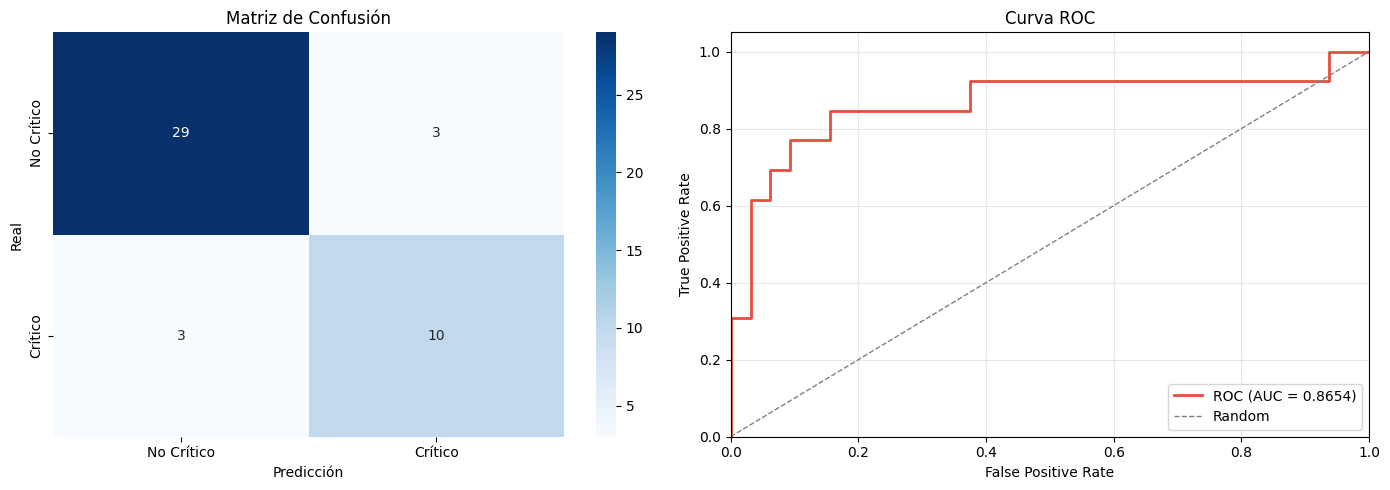

In [14]:
# =============================================================================
# 10. EVALUACIÓN FINAL EN TEST
# =============================================================================

# Predicciones
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Métricas
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
roc = roc_auc_score(y_test, y_proba_test)

print("="*60)
print("EVALUACIÓN FINAL EN TEST SET")
print("="*60)
print(f"\n   Accuracy:  {acc:.4f}")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc:.4f}")

# Classification Report completo
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_test, target_names=['No Crítico', 'Crítico']))

# --- Matriz de Confusión ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Crítico', 'Crítico'],
            yticklabels=['No Crítico', 'Crítico'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

TOP 20 FEATURES POR IMPORTANCIA (GAIN)
   proporcion_linea_critica            [OPERATIVA]  0.1947
   H1_SUM_PERS                         [TDA]        0.0926
   DESTINO                             [OPERATIVA]  0.0648
   frecuencia_viajes                   [OPERATIVA]  0.0512
   PLANTA_ORIGEN                       [OPERATIVA]  0.0483
   tiempo_transito_promedio_h          [OPERATIVA]  0.0457
   participacion_total                 [OPERATIVA]  0.0450
   tiempo_programacion_std_h           [OPERATIVA]  0.0387
   H0_N_FEATURES                       [TDA]        0.0382
   proporcion_anomalia_tiempo          [OPERATIVA]  0.0347
   LANDSCAPE_04                        [TDA]        0.0344
   tiempo_transito_std_h               [OPERATIVA]  0.0318
   H0_MEAN_PERS                        [TDA]        0.0235
   H0_TOP3_PERS                        [TDA]        0.0230
   H1_N_FEATURES                       [TDA]        0.0224
   tiempo_transito_mediano_h           [OPERATIVA]  0.0209
   LANDSCAPE_08  

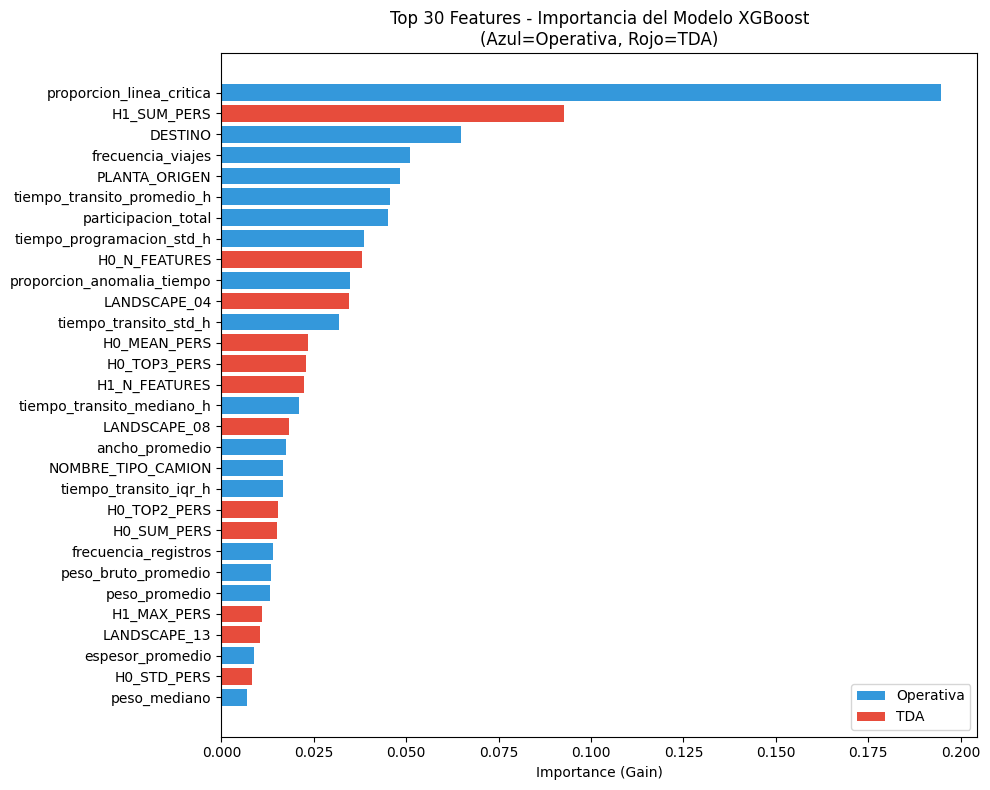


IMPORTANCIA ACUMULADA POR BLOQUE
              sum    mean  count  pct_total
bloque                                     
OPERATIVA  0.6831  0.0297     23  68.314598
TDA        0.3169  0.0122     26  31.685400

━━ Features TDA en Top 10: 2 de 10
   - H1_SUM_PERS: 0.0926
   - H0_N_FEATURES: 0.0382


In [15]:
# =============================================================================
# 11. INTERPRETABILIDAD - FEATURE IMPORTANCE
# =============================================================================

# --- 11.1 Feature Importance nativa de XGBoost (gain) ---
importance_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Clasificar cada feature como OPERATIVA o TDA
importance_df['bloque'] = importance_df['feature'].apply(
    lambda f: 'TDA' if f in FEATURES_TDA else 'OPERATIVA'
)

# Top 20 features
print("="*60)
print("TOP 20 FEATURES POR IMPORTANCIA (GAIN)")
print("="*60)
for i, row in importance_df.head(20).iterrows():
    tag = f"[{row['bloque']}]"
    print(f"   {row['feature']:35s} {tag:12s} {row['importance']:.4f}")

# --- Gráfica de importancia de variables ---
top_n = min(30, len(importance_df))
plot_df = importance_df.head(top_n).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if b == 'TDA' else '#3498db' for b in plot_df['bloque']]
ax.barh(plot_df['feature'], plot_df['importance'], color=colors)
ax.set_xlabel('Importance (Gain)')
ax.set_title(f'Top {top_n} Features - Importancia del Modelo XGBoost\n(Azul=Operativa, Rojo=TDA)')
ax.axvline(x=0, color='gray', linewidth=0.5)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Operativa'),
    Patch(facecolor='#e74c3c', label='TDA')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# --- Resumen por bloque ---
print(f"\n{'='*60}")
print("IMPORTANCIA ACUMULADA POR BLOQUE")
print("="*60)
bloque_summary = importance_df.groupby('bloque')['importance'].agg(['sum', 'mean', 'count'])
bloque_summary['pct_total'] = bloque_summary['sum'] / importance_df['importance'].sum() * 100
print(bloque_summary.round(4))

# Features TDA en top 10
top10_tda = importance_df.head(10).query("bloque == 'TDA'")
print(f"\n━━ Features TDA en Top 10: {len(top10_tda)} de 10")
if len(top10_tda) > 0:
    for _, row in top10_tda.iterrows():
        print(f"   - {row['feature']}: {row['importance']:.4f}")

Calculando SHAP values (esto puede tomar unos minutos)...

━━ SHAP Summary Plot (Top 20 features):


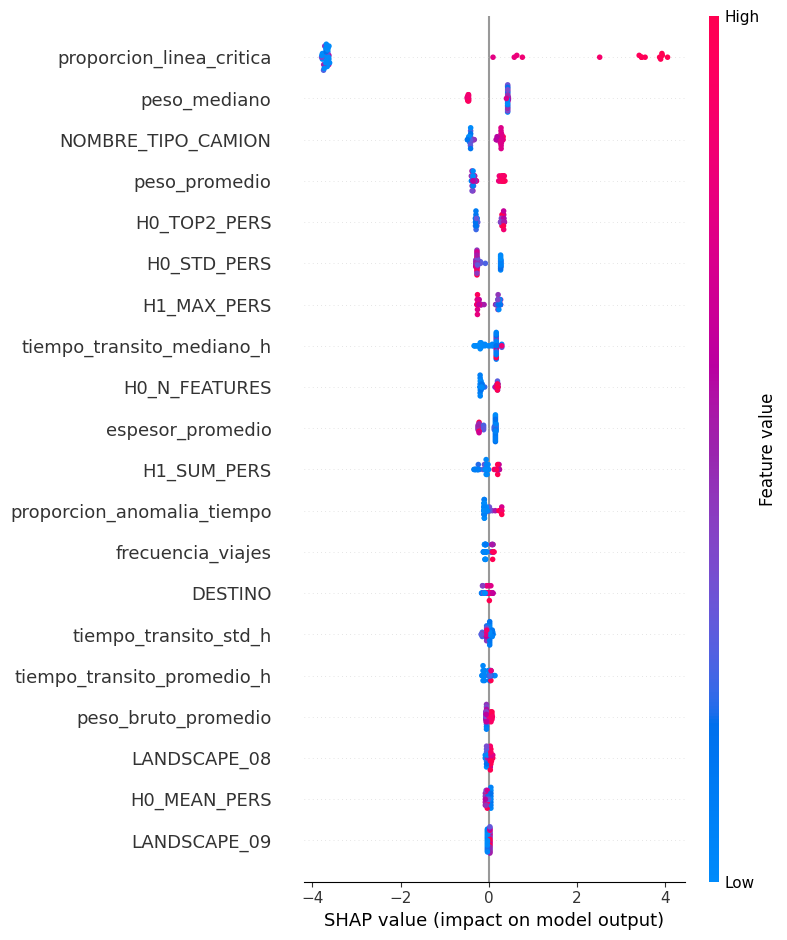


━━ SHAP: Importancia media absoluta por bloque:
              sum    mean  pct_total
bloque                              
OPERATIVA  5.3874  0.2342  80.419098
TDA        1.3118  0.0505  19.580900

━━ SHAP Bar Plot (Top 20):


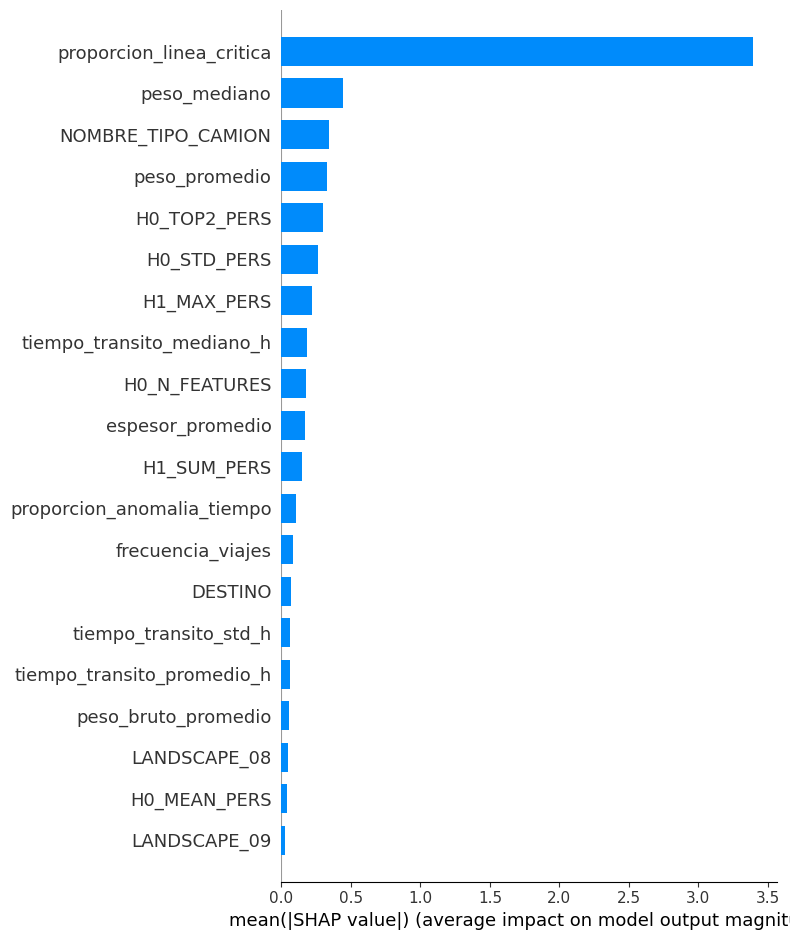

In [16]:
# =============================================================================
# 12. INTERPRETABILIDAD - SHAP VALUES
# =============================================================================
# SHAP proporciona atribución aditiva por feature a nivel de instancia.
# Permite entender QUÉ features empujan la predicción hacia "crítico".

if SHAP_AVAILABLE:
    print("Calculando SHAP values (esto puede tomar unos minutos)...")

    # Usar TreeExplainer (eficiente para modelos basados en árboles)
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    # --- Summary plot (beeswarm) ---
    print("\n━━ SHAP Summary Plot (Top 20 features):")
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES,
                      max_display=20, show=False)
    plt.tight_layout()
    plt.show()

    # --- SHAP importance por bloque ---
    shap_importance = pd.DataFrame({
        'feature': ALL_FEATURES,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

    shap_importance['bloque'] = shap_importance['feature'].apply(
        lambda f: 'TDA' if f in FEATURES_TDA else 'OPERATIVA'
    )

    print("\n━━ SHAP: Importancia media absoluta por bloque:")
    shap_bloque = shap_importance.groupby('bloque')['mean_abs_shap'].agg(['sum', 'mean'])
    shap_bloque['pct_total'] = shap_bloque['sum'] / shap_importance['mean_abs_shap'].sum() * 100
    print(shap_bloque.round(4))

    # --- Bar plot SHAP ---
    print("\n━━ SHAP Bar Plot (Top 20):")
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES,
                      plot_type='bar', max_display=20, show=False)
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ SHAP no disponible. Instalar con: %pip install shap")
    print("Se usó feature importance nativa de XGBoost en la celda anterior.")

In [17]:
# =============================================================================
# 13. ANÁLISIS DEL APORTE TDA Y ESTRUCTURA PARA COMPARACIÓN FUTURA
# =============================================================================

print("="*60)
print("ANÁLISIS DEL APORTE DE FEATURES TOPOLÓGICAS (TDA)")
print("="*60)

# --- 13.1 Listado formal de bloques ---
print(f"\n━━ BLOQUE OPERATIVO ({len(FEATURES_OPERATIVAS)} features):")
for f in FEATURES_OPERATIVAS:
    print(f"   - {f}")

print(f"\n━━ BLOQUE TDA ({len(FEATURES_TDA)} features):")
for f in FEATURES_TDA:
    print(f"   - {f}")

# --- 13.2 Contribución relativa del TDA ---
print(f"\n{'='*60}")
print("CONTRIBUCIÓN RELATIVA DEL BLOQUE TDA")
print("="*60)

imp_operativa = importance_df[importance_df['bloque'] == 'OPERATIVA']['importance'].sum()
imp_tda = importance_df[importance_df['bloque'] == 'TDA']['importance'].sum()
imp_total = imp_operativa + imp_tda

print(f"   Importancia acumulada OPERATIVA: {imp_operativa:.4f} ({imp_operativa/imp_total*100:.1f}%)")
print(f"   Importancia acumulada TDA:       {imp_tda:.4f} ({imp_tda/imp_total*100:.1f}%)")

# --- 13.3 Recomendación metodológica para comparación ---
print(f"\n{'='*60}")
print("RECOMENDACIÓN METODOLÓGICA PARA COMPARACIÓN FUTURA")
print("="*60)
print("""
Para comparar rigurosamente el modelo TDA vs el modelo tradicional:

1. MODELO TRADICIONAL (baseline):
   - Usar SOLO features del bloque OPERATIVO (las 23 features listadas arriba)
   - Mismo preprocesamiento (OrdinalEncoder, imputación mediana)
   - Mismo split de datos (MISMO random_state=42)
   - Misma optimización con Optuna (mismo n_trials, misma métrica F1)

2. MODELO TDA (este pipeline):
   - Usa features OPERATIVAS + TDA (23 + 26 = 49 features)

3. COMPARACIÓN JUSTA:
   - Comparar métricas en el MISMO test set
   - Usar test pareado (McNemar test) para significancia estadística
   - Reportar intervalos de confianza via bootstrap
   - Comparar: F1, Recall, ROC-AUC

4. ABLATION STUDY (opcional, más robusto):
   - Modelo solo operativo: FEATURES_OPERATIVAS
   - Modelo solo TDA: FEATURES_TDA
   - Modelo combinado: ALL_FEATURES
   - Esto permite medir la señal independiente del TDA

5. CÓDIGO PARA MODELO TRADICIONAL:
   Para entrenar el baseline, simplemente cambiar:
   >>> ALL_FEATURES = FEATURES_OPERATIVAS  # Solo operativas
   Y re-ejecutar el pipeline desde la celda 6 en adelante.
""")

# --- 13.4 Exportar resultados clave ---
resultados_modelo = {
    'modelo': 'XGBoost + TDA',
    'n_features_total': len(ALL_FEATURES),
    'n_features_operativas': len(FEATURES_OPERATIVAS),
    'n_features_tda': len(FEATURES_TDA),
    'accuracy_test': acc,
    'precision_test': prec,
    'recall_test': rec,
    'f1_test': f1,
    'roc_auc_test': roc,
    'pct_importancia_tda': imp_tda / imp_total * 100,
    'best_params': best_params,
}

print(f"\n━━ Resultados exportados en variable 'resultados_modelo'")
print(f"   (Usar para comparación futura contra modelo tradicional)")

ANÁLISIS DEL APORTE DE FEATURES TOPOLÓGICAS (TDA)

━━ BLOQUE OPERATIVO (23 features):
   - PLANTA_ORIGEN
   - DESTINO
   - NOMBRE_TIPO_CAMION
   - frecuencia_registros
   - tiempo_programacion_mediano_h
   - tiempo_programacion_promedio_h
   - tiempo_programacion_std_h
   - tiempo_transito_mediano_h
   - tiempo_transito_promedio_h
   - tiempo_transito_std_h
   - tiempo_transito_iqr_h
   - peso_promedio
   - peso_mediano
   - peso_bruto_promedio
   - ancho_promedio
   - espesor_promedio
   - proporcion_linea_critica
   - proporcion_viaje_incompleto
   - proporcion_anomalia_tiempo
   - frecuencia_viajes
   - participacion_total
   - material_pesado
   - material_ancho

━━ BLOQUE TDA (26 features):
   - H0_N_FEATURES
   - H0_MAX_PERS
   - H0_MEAN_PERS
   - H0_SUM_PERS
   - H0_STD_PERS
   - H0_TOP1_PERS
   - H0_TOP2_PERS
   - H0_TOP3_PERS
   - H1_N_FEATURES
   - H1_MAX_PERS
   - H1_SUM_PERS
   - LANDSCAPE_01
   - LANDSCAPE_02
   - LANDSCAPE_03
   - LANDSCAPE_04
   - LANDSCAPE_05
   - LANDS

# Resumen Interpretativo y Checklist Metodológico

## Interpretación de Resultados Esperados

### Desempeño del modelo
- **F1-score** es la métrica principal: balancea precisión y recall para circuitos críticos.
- **Recall > 0.80** es deseable: en contexto operativo, es peor no detectar un circuito crítico (falso negativo) que generar una alerta falsa (falso positivo).
- **ROC-AUC > 0.85** indica buena capacidad discriminativa global.

### Qué variables suelen dominar
- Variables de **tiempo de tránsito** (mediano, promedio, std, IQR) típicamente son las más informativas.
- **proporcion_linea_critica** y **proporcion_anomalia_tiempo** capturan señal directa.
- Del bloque TDA: **H0_MAX_PERS** y **H0_MEAN_PERS** suelen aparecer en top 15 si hay señal topológica real.

### ¿Aporta el TDA?
- Si las features TDA acumulan >15-20% de importancia total → hay señal topológica complementaria.
- Si <5% → las features operativas dominan y el TDA aporta poco.
- Las **persistence landscapes** capturan información funcional de la distribución de persistencia; si aparecen en top 20, sugieren estructura topológica no capturada por estadísticas simples.

---

## Notas sobre la Topología Computacional Aplicada

- **H0 (componentes conexas):** La persistencia en H0 captura la estructura de conectividad del circuito logístico. Alta persistencia H0 sugiere clusters bien separados en el espacio de operación.
- **H1 (ciclos):** Persistencia en H1 detecta ciclos (loops) en la estructura topológica de los datos operativos, lo que puede indicar patrones recurrentes o redundancia en rutas.
- **Persistence Landscapes:** Vectorización funcional del diagrama de persistencia que permite integración directa con ML. Las landscapes \(\lambda_k\) capturan las k features topológicas más persistentes como funciones reales, preservando estabilidad (Teorema de Estabilidad de Landscapes).